# model 학습
| 모델                                   | 특징                          | 추천 이유                        |
| ------------------------------------ | --------------------------- | ---------------------------- |
| **Random Forest**                    | 비선형 분류 + Feature Importance | 샘플 수 적정, 해석 가능, 과적합에 강함      |
| **XGBoost**                          | 비선형, 성능 최적화, 불균형 대응         | 가중치 조절, 고성능, SHAP 분석 가능      |
| **SVC (RBF 커널)**                     | 비선형 경계 학습                   | t-SNE/UMAP 분포에서 효과적          |
| **Logistic Regression (ElasticNet)** | 선형 + 해석 가능                  | 해석력 우선시 시도 (PLS/PCA에서 분리될 때) |
| **K-Nearest Neighbors (KNN)**        | 지역기반 비선형                    | UMAP에서 국지적 패턴 분명할 때 유용       |


## ===============================

## .pkl 파일 불러오기

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from IPython.display import display
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 경로 설정
save_dir = "/Users/taehokim/lab/BRL_AI/BRL_final/CLR_pkl"

# 1. 변화율 Top 10 feature 데이터 불러오기
top10_data_path = os.path.join(save_dir, "all_top10_data.pkl")
with open(top10_data_path, 'rb') as f:
    all_top10_data = pickle.load(f)

# 2. 변화율 분석 결과 불러오기
change_analysis_path = os.path.join(save_dir, "change_analysis_results.pkl")
with open(change_analysis_path, 'rb') as f:
    change_analysis_results = pickle.load(f)

## 1. TPC 먼저 모델 학습

In [2]:
# 3. TPC 라벨 생성 및 데이터 준비

# TPC 최적 임계값 설정
TPC_THR_LOW = 4.369
TPC_THR_HIGH = 6.427

# 라벨 생성 함수
def create_tpc_labels(df, tpc_col='TPC (log CFU/g)', 
                      tpc_low=TPC_THR_LOW, tpc_high=TPC_THR_HIGH):
    """TPC 값을 기준으로 라벨 생성"""
    conditions = [
        df[tpc_col] < tpc_low,      # Fresh
        df[tpc_col] >= tpc_high,    # Decay
    ]
    choices = [0, 1]  # Fresh=0, Decay=1
    labels = np.select(conditions, choices, default=2)  # Middle=2
    return labels

# 라벨명 매핑
LABEL_NAMES = {0: 'Fresh', 1: 'Decay', 2: 'Middle'}
LABEL_COLORS = {0: 'green', 1: 'red', 2: 'orange'}

# 4. 모든 taxonomy level에 라벨 추가 (Top 10 feature만 사용)
final_taxonomic_levels_with_label = []

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    top10_df = all_top10_data[level_name]['top10_data'].copy()
    # 라벨 생성
    top10_df['Label'] = create_tpc_labels(top10_df)
    # Day 컬럼 추가
    top10_df['Day'] = top10_df['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    final_taxonomic_levels_with_label.append((level_name, top10_df))

    print(f"\n=== {level_name} Level ===")
    print(f"Shape: {top10_df.shape}")
    feature_cols = all_top10_data[level_name]['top_10_feature_names']
    print(f"미생물 Feature 수: {len(feature_cols)}")
    label_counts = np.bincount(top10_df['Label'])
    total = len(top10_df)
    for i, count in enumerate(label_counts):
        name = LABEL_NAMES[i]
        percentage = count / total * 100
        print(f"{name}: {count}개 ({percentage:.1f}%)")

print(f"\n=== 라벨 생성 완료 ===")
print(f"임계값: Fresh < {TPC_THR_LOW}, Decay ≥ {TPC_THR_HIGH}")


=== Phylum Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 154개 (57.0%)
Decay: 35개 (13.0%)
Middle: 81개 (30.0%)

=== Class Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 154개 (57.0%)
Decay: 35개 (13.0%)
Middle: 81개 (30.0%)

=== Order Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 154개 (57.0%)
Decay: 35개 (13.0%)
Middle: 81개 (30.0%)

=== Family Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 154개 (57.0%)
Decay: 35개 (13.0%)
Middle: 81개 (30.0%)

=== Genus Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 154개 (57.0%)
Decay: 35개 (13.0%)
Middle: 81개 (30.0%)

=== 라벨 생성 완료 ===
임계값: Fresh < 4.369, Decay ≥ 6.427


# TPC 모델 학습

In [3]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 사용할 모델과 파라미터 그리드 정의 (Pipeline 적용, prefix 적용)
model_configs = {
    "RandomForest": {
        "model": RandomForestClassifier,
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier,
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1]
        }
    },
    "SVC": {
        "model": lambda: Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC())
        ]),
        "params": {
            "svc__C": [0.5, 1, 2],
            "svc__gamma": ["scale", "auto"],
            "svc__kernel": ["rbf"],
            "svc__probability": [True],
            "svc__class_weight": ["balanced"]
        }
    },
    "LogisticRegression": {
        "model": lambda: Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression())
        ]),
        "params": {
            "lr__penalty": ["elasticnet"],
            "lr__solver": ["saga"],
            "lr__l1_ratio": [0.2, 0.5, 0.8],
            "lr__C": [0.5, 1, 2],
            "lr__max_iter": [500],
            "lr__class_weight": ["balanced"],
            "lr__multi_class": ["multinomial"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier,
        "params": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
        }
    }
}
taxonomy_levels = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

# 결과 저장 딕셔너리
all_model_results = {}

for level_name in taxonomy_levels:
    print(f"\n{'='*60}\n=== {level_name} Level 모델 학습 시작 ===\n{'='*60}")
    level_data = final_taxonomic_levels_with_label[[x[0] for x in final_taxonomic_levels_with_label].index(level_name)][1]
    feature_cols = [col for col in level_data.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS', 'Label', 'Day']]
    X = level_data[feature_cols].values
    y = level_data['Label'].values

    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    all_model_results[level_name] = {}

    for model_name, config in model_configs.items():
        print(f"\n--- {model_name} 학습 ---")
        # Pipeline/lambda는 함수로, 나머지는 클래스이므로 항상 ()로 인스턴스 생성
        model = config["model"]() if callable(config["model"]) else config["model"]()
        param_grid = config["params"]

        grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        best_params = grid.best_params_

        # 예측 및 평가
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        train_f1 = f1_score(y_train, y_train_pred, average='macro')
        test_f1 = f1_score(y_test, y_test_pred, average='macro')
        overfit_acc = train_acc - test_acc
        overfit_f1 = train_f1 - test_f1

        # 결과 저장
        all_model_results[level_name][model_name] = {
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "train_f1_score": train_f1,
            "test_f1_score": test_f1,
            "Overfitting_Acc": overfit_acc,
            "Overfitting_F1": overfit_f1,
            "Best_Params": best_params,
            "Best_Model": best_model,
            "GridSearchCV": grid  # grid 객체도 저장
        }

        print(f"Train Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}")
        print(f"Train F1: {train_f1:.3f}, Test F1: {test_f1:.3f}")
        print(f"Overfitting Acc: {overfit_acc:.3f}, Overfitting F1: {overfit_f1:.3f}")
        print(f"Best Params: {best_params}")

print("\n=== 모든 모델 학습 및 평가 완료 ===")

# GridSearchCV로 찾은 하이퍼파라미터 전체 출력
print("\n===== GridSearchCV Best Params 전체 출력 =====")
for level_name in taxonomy_levels:
    print(f"\n[{level_name}]")
    for model_name in model_configs.keys():
        params = all_model_results[level_name][model_name]["Best_Params"]
        print(f"{model_name}: {params}")


=== Phylum Level 모델 학습 시작 ===

--- RandomForest 학습 ---
Train Acc: 0.912, Test Acc: 0.759
Train F1: 0.851, Test F1: 0.682
Overfitting Acc: 0.153, Overfitting F1: 0.169
Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

--- XGBoost 학습 ---
Train Acc: 1.000, Test Acc: 0.741
Train F1: 1.000, Test F1: 0.677
Overfitting Acc: 0.259, Overfitting F1: 0.323
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.852, Test Acc: 0.704
Train F1: 0.792, Test F1: 0.662
Overfitting Acc: 0.148, Overfitting F1: 0.130
Best Params: {'svc__C': 2, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf', 'svc__probability': True}

--- LogisticRegression 학습 ---


/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.782, Test Acc: 0.667
Train F1: 0.707, Test F1: 0.625
Overfitting Acc: 0.116, Overfitting F1: 0.082
Best Params: {'lr__C': 1, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.8, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 1.000, Test Acc: 0.741
Train F1: 1.000, Test F1: 0.695
Overfitting Acc: 0.259, Overfitting F1: 0.305
Best Params: {'n_neighbors': 7, 'weights': 'distance'}

=== Class Level 모델 학습 시작 ===

--- RandomForest 학습 ---
Train Acc: 0.981, Test Acc: 0.722
Train F1: 0.975, Test F1: 0.618
Overfitting Acc: 0.259, Overfitting F1: 0.357
Best Params: {'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 100}

--- XGBoost 학습 ---
Train Acc: 0.977, Test Acc: 0.685
Train F1: 0.976, Test F1: 0.558
Overfitting Acc: 0.292, Overfitting F1: 0.417
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.870, Test Acc: 0.630
Train F1: 0.838, Test 

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.819, Test Acc: 0.648
Train F1: 0.748, Test F1: 0.598
Overfitting Acc: 0.171, Overfitting F1: 0.150
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.8, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 1.000, Test Acc: 0.741
Train F1: 1.000, Test F1: 0.688
Overfitting Acc: 0.259, Overfitting F1: 0.312
Best Params: {'n_neighbors': 3, 'weights': 'distance'}

=== Order Level 모델 학습 시작 ===

--- RandomForest 학습 ---
Train Acc: 0.968, Test Acc: 0.648
Train F1: 0.960, Test F1: 0.433
Overfitting Acc: 0.319, Overfitting F1: 0.527
Best Params: {'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 100}

--- XGBoost 학습 ---
Train Acc: 1.000, Test Acc: 0.685
Train F1: 1.000, Test F1: 0.549
Overfitting Acc: 0.315, Overfitting F1: 0.451
Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.833, Test Acc: 0.741
Train F1: 0.791, Tes

...

Train Acc: 0.819, Test Acc: 0.796
Train F1: 0.761, Test F1: 0.744
Overfitting Acc: 0.023, Overfitting F1: 0.017
Best Params: {'lr__C': 1, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.2, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 1.000, Test Acc: 0.685
Train F1: 1.000, Test F1: 0.567
Overfitting Acc: 0.315, Overfitting F1: 0.433
Best Params: {'n_neighbors': 5, 'weights': 'distance'}

=== Family Level 모델 학습 시작 ===

--- RandomForest 학습 ---
Train Acc: 0.921, Test Acc: 0.852
Train F1: 0.894, Test F1: 0.858
Overfitting Acc: 0.069, Overfitting F1: 0.037
Best Params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}

--- XGBoost 학습 ---
Train Acc: 1.000, Test Acc: 0.833
Train F1: 1.000, Test F1: 0.840
Overfitting Acc: 0.167, Overfitting F1: 0.160
Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

--- SVC 학습 ---
Train Acc: 0.917, Test Acc: 0.833
Train F1: 0.897, Test 

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.894, Test Acc: 0.815
Train F1: 0.863, Test F1: 0.810
Overfitting Acc: 0.079, Overfitting F1: 0.053
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.2, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 1.000, Test Acc: 0.852
Train F1: 1.000, Test F1: 0.858
Overfitting Acc: 0.148, Overfitting F1: 0.142
Best Params: {'n_neighbors': 5, 'weights': 'distance'}

=== Genus Level 모델 학습 시작 ===

--- RandomForest 학습 ---
Train Acc: 0.949, Test Acc: 0.833
Train F1: 0.929, Test F1: 0.844
Overfitting Acc: 0.116, Overfitting F1: 0.085
Best Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

--- XGBoost 학습 ---
Train Acc: 1.000, Test Acc: 0.815
Train F1: 1.000, Test F1: 0.827
Overfitting Acc: 0.185, Overfitting F1: 0.173
Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.912, Test Acc: 0.833
Train F1: 0.884, Tes

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.907, Test Acc: 0.815
Train F1: 0.872, Test F1: 0.810
Overfitting Acc: 0.093, Overfitting F1: 0.062
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.2, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 1.000, Test Acc: 0.833
Train F1: 1.000, Test F1: 0.820
Overfitting Acc: 0.167, Overfitting F1: 0.180
Best Params: {'n_neighbors': 5, 'weights': 'distance'}

=== 모든 모델 학습 및 평가 완료 ===

===== GridSearchCV Best Params 전체 출력 =====

[Phylum]
RandomForest: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
SVC: {'svc__C': 2, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf', 'svc__probability': True}
LogisticRegression: {'lr__C': 1, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.8, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 

## middle 분류 dataset 회귀 모델로 전환

In [4]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.base import BaseEstimator, RegressorMixin
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf

def create_lstm_model(input_shape, units, dropout):
    """LSTM 모델 생성"""
    model = Sequential([
        LSTM(units, return_sequences=False, input_shape=input_shape),
        Dropout(dropout),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', run_eagerly=False)
    return model

class LSTMRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, units=32, dropout=0.1, epochs=10, batch_size=16, patience=5):
        self.units = units
        self.dropout = dropout
        self.epochs = epochs
        self.batch_size = batch_size
        self.patience = patience
        self.model = None
        self.scaler = StandardScaler()
        self.input_shape = None

    def fit(self, X, y):
        X_scaled = self.scaler.fit_transform(X)
        self.input_shape = (1, X_scaled.shape[1])
        X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
        self.model = create_lstm_model(self.input_shape, self.units, self.dropout)
        early_stop = EarlyStopping(monitor='loss', patience=self.patience, restore_best_weights=True)
        self.model.fit(X_reshaped, y, epochs=self.epochs, batch_size=self.batch_size,
                       callbacks=[early_stop], verbose=0)
        return self

    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
        return self.model.predict(X_reshaped, verbose=0).flatten()

def calculate_rsd(y_true, y_pred):
    """Relative Standard Deviation 계산"""
    residuals = y_true - y_pred
    rsd = np.std(residuals) / np.mean(y_true) * 100
    return rsd

# GridSearch 파라미터 설정 (LSTM 에포치/배치/유닛/드롭아웃 최소화)
param_grids = {
    "LightGBM": {
        "n_estimators": [100],
        "max_depth": [3],
        "learning_rate": [0.05],
        "num_leaves": [31]
    },
    "RandomForest": {
        "n_estimators": [100],
        "max_depth": [3],
        "min_samples_split": [2]
    },
    "XGBoost": {
        "n_estimators": [100],
        "max_depth": [3],
        "learning_rate": [0.05]
    },
    "SVR": {
        "C": [1],
        "gamma": ["scale"],
        "kernel": ["rbf"]
    },
    "LSTM": {
        "units": [16],           # 최소 유닛
        "dropout": [0.1],        # 최소 드롭아웃
        "epochs": [5],           # 에포치 최소화
        "batch_size": [8]        # 배치 최소화
    }
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

regression_results = {}

# Genus level만 실행
for level_name, level_df in final_taxonomic_levels_with_label:
    if level_name != "Genus":
        continue

    fresh_middle_df = level_df[level_df['Label'].isin([0, 2])].copy()
    feature_cols = [col for col in fresh_middle_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS', 'Label', 'Day']]
    X = fresh_middle_df[feature_cols].values
    y = fresh_middle_df['TPC (log CFU/g)'].values

    if len(fresh_middle_df) < 10:
        print(f"{level_name}: Fresh+Middle 샘플 수가 너무 적어 회귀 생략")
        continue

    print(f"\n=== {level_name} Level 회귀 분석 시작 ===")
    print(f"Fresh+Middle 샘플 수: {len(fresh_middle_df)}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    regressors = {
        "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
        "RandomForest": RandomForestRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42, verbosity=0),
        "SVR": Pipeline([('scaler', StandardScaler()), ('svr', SVR())]),
        "LSTM": LSTMRegressor()
    }

    regression_results[level_name] = {}

    for name, reg in regressors.items():
        print(f"\n--- {name} 학습 중 ---")
        if name == "SVR":
            param_grid = {"svr__" + k: v for k, v in param_grids["SVR"].items()}
        else:
            param_grid = param_grids[name]

        try:
            grid = GridSearchCV(reg, param_grid, cv=kf, scoring='neg_mean_squared_error',
                                n_jobs=-1 if name != "LSTM" else 1, verbose=0)
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
            best_params = grid.best_params_

            y_train_pred = best_model.predict(X_train)
            train_mae = mean_absolute_error(y_train, y_train_pred)
            train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
            train_r2 = r2_score(y_train, y_train_pred)
            train_rsd = calculate_rsd(y_train, y_train_pred)

            y_test_pred = best_model.predict(X_test)
            test_mae = mean_absolute_error(y_test, y_test_pred)
            test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
            test_r2 = r2_score(y_test, y_test_pred)
            test_rsd = calculate_rsd(y_test, y_test_pred)

            overfit_mae = train_mae - test_mae
            overfit_rmse = train_rmse - test_rmse
            overfit_r2 = train_r2 - test_r2
            overfit_rsd = train_rsd - test_rsd

            cv_mae_scores = -cross_val_score(best_model, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
            cv_rmse_scores = np.sqrt(-cross_val_score(best_model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error'))
            cv_r2_scores = cross_val_score(best_model, X_train, y_train, cv=kf, scoring='r2')

            cv_mae_mean = np.mean(cv_mae_scores)
            cv_rmse_mean = np.mean(cv_rmse_scores)
            cv_r2_mean = np.mean(cv_r2_scores)

            regression_results[level_name][name] = {
                "Train_MAE": train_mae,
                "Test_MAE": test_mae,
                "Train_RMSE": train_rmse,
                "Test_RMSE": test_rmse,
                "Train_R2": train_r2,
                "Test_R2": test_r2,
                "Train_RSD": train_rsd,
                "Test_RSD": test_rsd,
                "Overfit_MAE": overfit_mae,
                "Overfit_RMSE": overfit_rmse,
                "Overfit_R2": overfit_r2,
                "Overfit_RSD": overfit_rsd,
                "CV_MAE_Mean": cv_mae_mean,
                "CV_RMSE_Mean": cv_rmse_mean,
                "CV_R2_Mean": cv_r2_mean,
                "Best_Params": best_params,
                "GridSearchCV": grid
            }

            print(f"Train - MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R2: {train_r2:.3f}, RSD: {train_rsd:.2f}%")
            print(f"Test  - MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.3f}, RSD: {test_rsd:.2f}%")
            print(f"Overfit - MAE: {overfit_mae:.4f}, RMSE: {overfit_rmse:.4f}, R2: {overfit_r2:.3f}, RSD: {overfit_rsd:.2f}%")

        except Exception as e:
            print(f"{name} 모델 학습 중 오류 발생: {str(e)}")
            continue

print("\n=== Genus Level 회귀 결과 (GridSearchCV & 5-Fold CV) ===")
for level_name, res in regression_results.items():
    print(f"\n[{level_name}]")
    for model_name, metrics in res.items():
        print(f"{model_name}:")
        print(f"  Test Performance - MAE: {metrics['Test_MAE']:.4f}, RMSE: {metrics['Test_RMSE']:.4f}, R2: {metrics['Test_R2']:.3f}, RSD: {metrics['Test_RSD']:.2f}%")
        print(f"  Overfitting - MAE: {metrics['Overfit_MAE']:.4f}, RMSE: {metrics['Overfit_RMSE']:.4f}, R2: {metrics['Overfit_R2']:.3f}")

# 결과 엑셀 저장
result_dir = "model_result"
os.makedirs(result_dir, exist_ok=True)
excel_path = os.path.join(result_dir, "regression_genus_only_result.xlsx")

rows = []
for level_name, res_dict in regression_results.items():
    for model_name, metrics in res_dict.items():
        row = {
            "Taxonomy_Level": level_name,
            "Model": model_name,
            "Train_MAE": metrics["Train_MAE"],
            "Test_MAE": metrics["Test_MAE"],
            "Train_RMSE": metrics["Train_RMSE"],
            "Test_RMSE": metrics["Test_RMSE"],
            "Train_R2": metrics["Train_R2"],
            "Test_R2": metrics["Test_R2"],
            "Train_RSD": metrics["Train_RSD"],
            "Test_RSD": metrics["Test_RSD"],
            "Overfit_MAE": metrics["Overfit_MAE"],
            "Overfit_RMSE": metrics["Overfit_RMSE"],
            "Overfit_R2": metrics["Overfit_R2"],
            "Overfit_RSD": metrics["Overfit_RSD"],
            "CV_MAE_Mean": metrics["CV_MAE_Mean"],
            "CV_RMSE_Mean": metrics["CV_RMSE_Mean"],
            "CV_R2_Mean": metrics["CV_R2_Mean"],
            "Best_Params": str(metrics["Best_Params"])
        }
        rows.append(row)

df_result = pd.DataFrame(rows)
df_result.to_excel(excel_path, index=False)
print(f"\n회귀 모델 성능 결과가 '{excel_path}'에 저장되었습니다.")

2025-09-11 13:53:18.112179: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



=== Genus Level 회귀 분석 시작 ===
Fresh+Middle 샘플 수: 235

--- LightGBM 학습 중 ---
Train - MAE: 0.2796, RMSE: 0.3578, R2: 0.870, RSD: 8.28%
Test  - MAE: 0.4353, RMSE: 0.5888, R2: 0.735, RSD: 13.06%
Overfit - MAE: -0.1557, RMSE: -0.2310, R2: 0.135, RSD: -4.79%

--- RandomForest 학습 중 ---
Train - MAE: 0.3239, RMSE: 0.4069, R2: 0.832, RSD: 9.41%
Test  - MAE: 0.4511, RMSE: 0.5888, R2: 0.735, RSD: 13.01%
Overfit - MAE: -0.1271, RMSE: -0.1819, R2: 0.097, RSD: -3.60%

--- XGBoost 학습 중 ---
Train - MAE: 0.2096, RMSE: 0.2677, R2: 0.927, RSD: 6.19%
Test  - MAE: 0.4343, RMSE: 0.5838, R2: 0.739, RSD: 12.84%
Overfit - MAE: -0.2247, RMSE: -0.3161, R2: 0.188, RSD: -6.64%

--- SVR 학습 중 ---
Train - MAE: 0.2962, RMSE: 0.4187, R2: 0.822, RSD: 9.69%
Test  - MAE: 0.4224, RMSE: 0.5847, R2: 0.739, RSD: 12.97%
Overfit - MAE: -0.1263, RMSE: -0.1660, R2: 0.084, RSD: -3.28%

--- LSTM 학습 중 ---
Train - MAE: 3.1313, RMSE: 3.2201, R2: -9.518, RSD: 17.38%
Test  - MAE: 3.2282, RMSE: 3.3514, R2: -7.587, RSD: 19.99%
Overfit - MA

## TPC 모델 성능 결과 엑셀 파일에 저장

In [5]:
import os
import pandas as pd

# 디렉토리 생성
result_dir = "model_result"
os.makedirs(result_dir, exist_ok=True)

# 분류 결과 DataFrame 생성 (Sheet1)
model_order = [
    "RandomForest", "XGBoost", "SVC", "LogisticRegression", "KNN"
]
taxonomy_order = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

result_rows = []
for level_name, model_dict in all_model_results.items():
    for model_name, res in model_dict.items():
        row = {
            "Model": model_name,
            "Level": level_name,
            "Train_Accuracy": res["train_accuracy"],
            "Test_Accuracy": res["test_accuracy"],
            "Train_F1_Macro": res["train_f1_score"],
            "Test_F1_Macro": res["test_f1_score"],
            "Overfitting_Acc": res["Overfitting_Acc"],
            "Overfitting_F1": res["Overfitting_F1"],
            "Best_Params": str(res["Best_Params"])
        }
        result_rows.append(row)

df_result = pd.DataFrame(result_rows)
df_result = df_result[[
    "Model", "Level", "Train_Accuracy", "Test_Accuracy", "Train_F1_Macro", "Test_F1_Macro", "Overfitting_Acc", "Overfitting_F1", "Best_Params"
]]

def overfit_flag(row):
    if abs(row["Overfitting_Acc"]) < 0.15 and abs(row["Overfitting_F1"]) < 0.15:
        return "🟩 Low"
    elif abs(row["Overfitting_Acc"]) < 0.3 and abs(row["Overfitting_F1"]) < 0.3:
        return "🟨 Caution"
    else:
        return "🟥 High"

df_result["Overfit_Status"] = df_result.apply(overfit_flag, axis=1)
model_name_map = {
    "RandomForest": "RandomForest",
    "XGBoost": "XGBoost",
    "SVC": "SVC",
    "LogisticRegression": "LogisticRegression",
    "KNN": "KNN"
}
df_result["Model"] = df_result["Model"].map(model_name_map).fillna(df_result["Model"])
df_result["Model"] = pd.Categorical(df_result["Model"], categories=model_order, ordered=True)
df_result["Level"] = pd.Categorical(df_result["Level"], categories=taxonomy_order, ordered=True)
df_result = df_result.sort_values(["Model", "Level"]).reset_index(drop=True)

# 회귀 결과 DataFrame 생성 (Sheet2) - 새로운 지표들로 업데이트
regression_model_order = [
    "LightGBM", "RandomForest", "XGBoost", "SVR", "LSTM"
]

regression_rows = []
for level_name, res_dict in regression_results.items():
    for model_name, metrics in res_dict.items():
        row = {
            "Level": level_name,
            "Regressor": model_name,
            "Train_MAE": metrics.get("Train_MAE", None),
            "Test_MAE": metrics.get("Test_MAE", None),
            "Train_RMSE": metrics.get("Train_RMSE", None),
            "Test_RMSE": metrics.get("Test_RMSE", None),
            "Train_R2": metrics.get("Train_R2", None),
            "Test_R2": metrics.get("Test_R2", None),
            "Train_RSD": metrics.get("Train_RSD", None),
            "Test_RSD": metrics.get("Test_RSD", None),
            "Overfit_MAE": metrics.get("Overfit_MAE", None),
            "Overfit_RMSE": metrics.get("Overfit_RMSE", None),
            "Overfit_R2": metrics.get("Overfit_R2", None),
            "Overfit_RSD": metrics.get("Overfit_RSD", None),
            "CV_MAE_Mean": metrics.get("CV_MAE_Mean", None),
            "CV_RMSE_Mean": metrics.get("CV_RMSE_Mean", None),
            "CV_R2_Mean": metrics.get("CV_R2_Mean", None),
            "Best_Params": str(metrics.get("Best_Params", None))
        }
        regression_rows.append(row)

df_regression = pd.DataFrame(regression_rows)

# 회귀 모델 정렬 및 카테고리 설정
regressor_name_map = {
    "LightGBM": "LightGBM",
    "RandomForest": "RandomForest",
    "XGBoost": "XGBoost",
    "SVR": "SVR",
    "LSTM": "LSTM"
}
df_regression["Regressor"] = df_regression["Regressor"].map(regressor_name_map).fillna(df_regression["Regressor"])
df_regression["Regressor"] = pd.Categorical(df_regression["Regressor"], categories=regression_model_order, ordered=True)
df_regression["Level"] = pd.Categorical(df_regression["Level"], categories=taxonomy_order, ordered=True)
df_regression = df_regression.sort_values(["Regressor", "Level"]).reset_index(drop=True)

df_regression = df_regression[[
    "Level", "Regressor", 
    "Train_MAE", "Test_MAE", 
    "Train_RMSE", "Test_RMSE", 
    "Train_R2", "Test_R2", 
    "Train_RSD", "Test_RSD",
    "Overfit_MAE", "Overfit_RMSE", "Overfit_R2", "Overfit_RSD",
    "CV_MAE_Mean", "CV_RMSE_Mean", "CV_R2_Mean",
    "Best_Params"
]]

# 엑셀로 저장 (Sheet1: 분류, Sheet2: 회귀)
excel_path = os.path.join(result_dir, "clr_optuna_변화_tpc_model_result.xlsx")
with pd.ExcelWriter(excel_path) as writer:
    df_result.to_excel(writer, sheet_name="Classification", index=False)
    df_regression.to_excel(writer, sheet_name="Regression", index=False)

print(f"분류/회귀 모델 성능 결과가 '{excel_path}'에 저장되었습니다.")

분류/회귀 모델 성능 결과가 'model_result/clr_optuna_변화_tpc_model_result.xlsx'에 저장되었습니다.


In [26]:
# ...회귀 결과 저장 직전...
regression_results[level_name][name] = {
    "Train_MAE": train_mae,
    "Test_MAE": test_mae,
    "Train_RMSE": train_rmse,
    "Test_RMSE": test_rmse,
    "Train_R2": train_r2,
    "Test_R2": test_r2,
    "Train_RSD": train_rsd,
    "Test_RSD": test_rsd,
    "Overfit_MAE": overfit_mae,
    "Overfit_RMSE": overfit_rmse,
    "Overfit_R2": overfit_r2,
    "Overfit_RSD": overfit_rsd,
    "CV_MAE_Mean": cv_mae_mean,
    "CV_RMSE_Mean": cv_rmse_mean,
    "CV_R2_Mean": cv_r2_mean,
    "Best_Params": best_params,
    "GridSearchCV": grid,
    # 아래 4개 추가!
    "y_train": y_train,
    "y_train_pred": y_train_pred,
    "y_test": y_test,
    "y_test_pred": y_test_pred
}

## 모델 예측 시각회

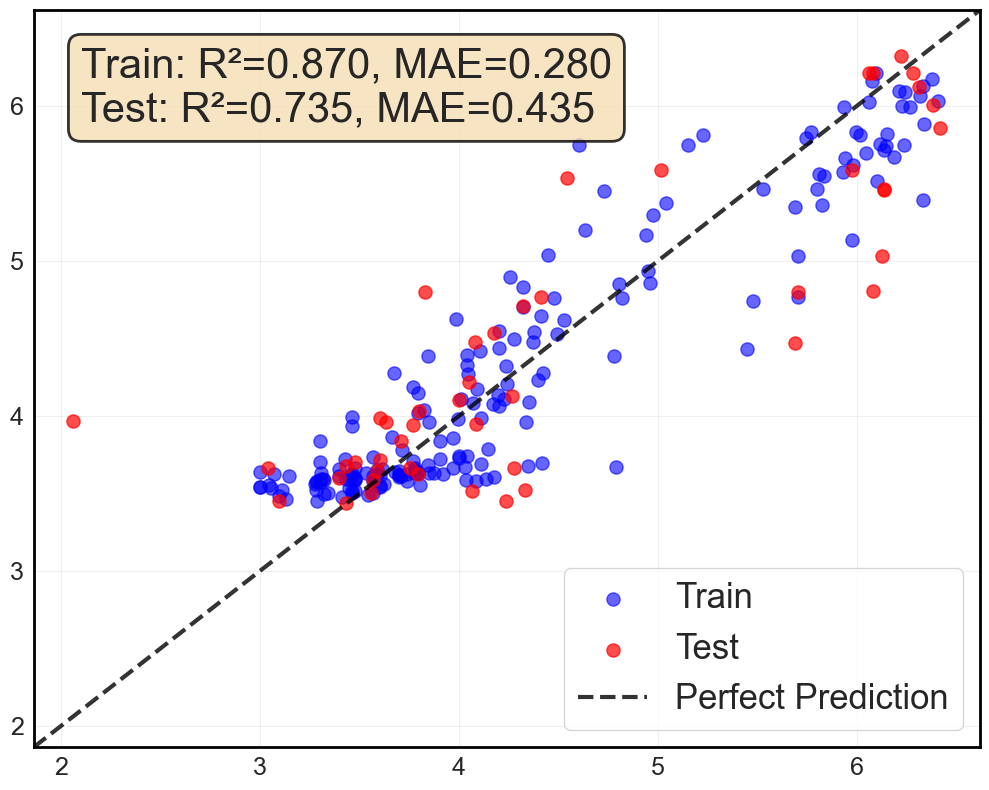

Genus - LightGBM 예측 vs 실제값 그래프가 'model_result/prediction_plots/Genus_LightGBM_regression_prediction_vs_actual.png'에 저장되었습니다.


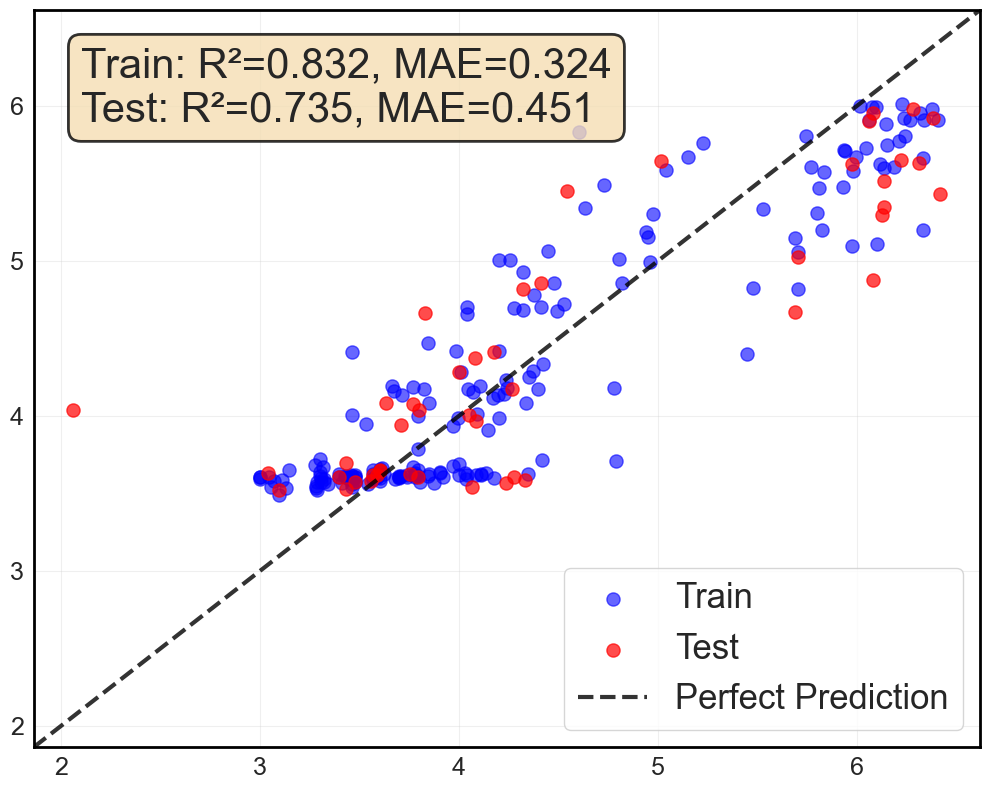

Genus - RandomForest 예측 vs 실제값 그래프가 'model_result/prediction_plots/Genus_RandomForest_regression_prediction_vs_actual.png'에 저장되었습니다.


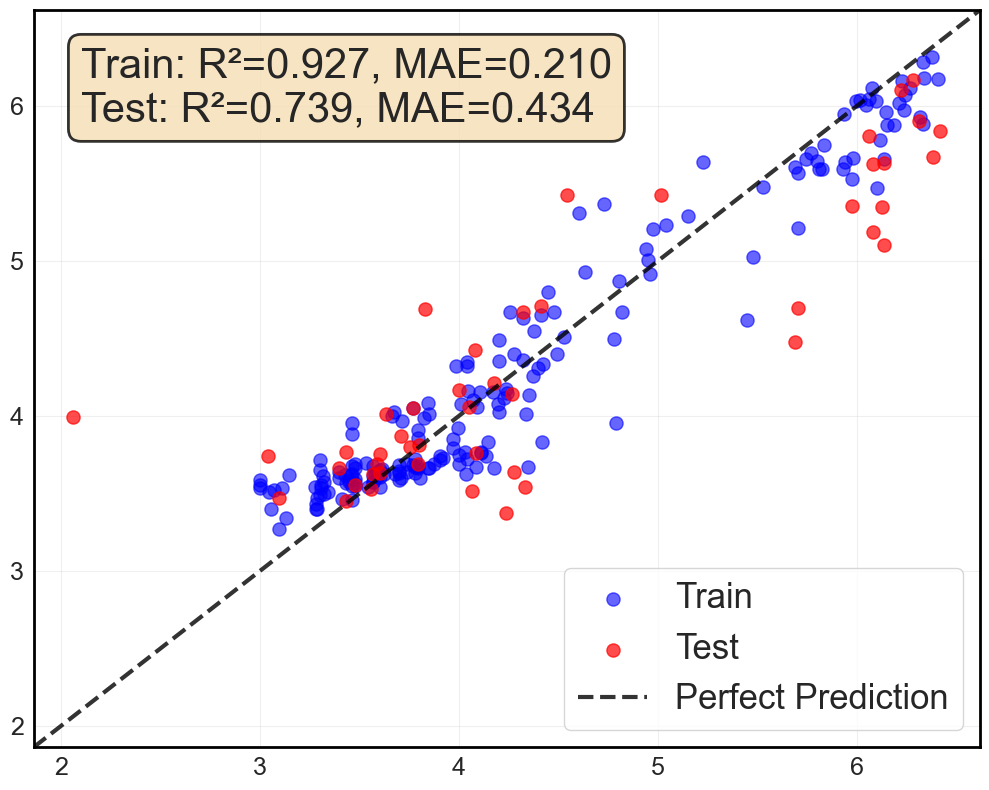

Genus - XGBoost 예측 vs 실제값 그래프가 'model_result/prediction_plots/Genus_XGBoost_regression_prediction_vs_actual.png'에 저장되었습니다.


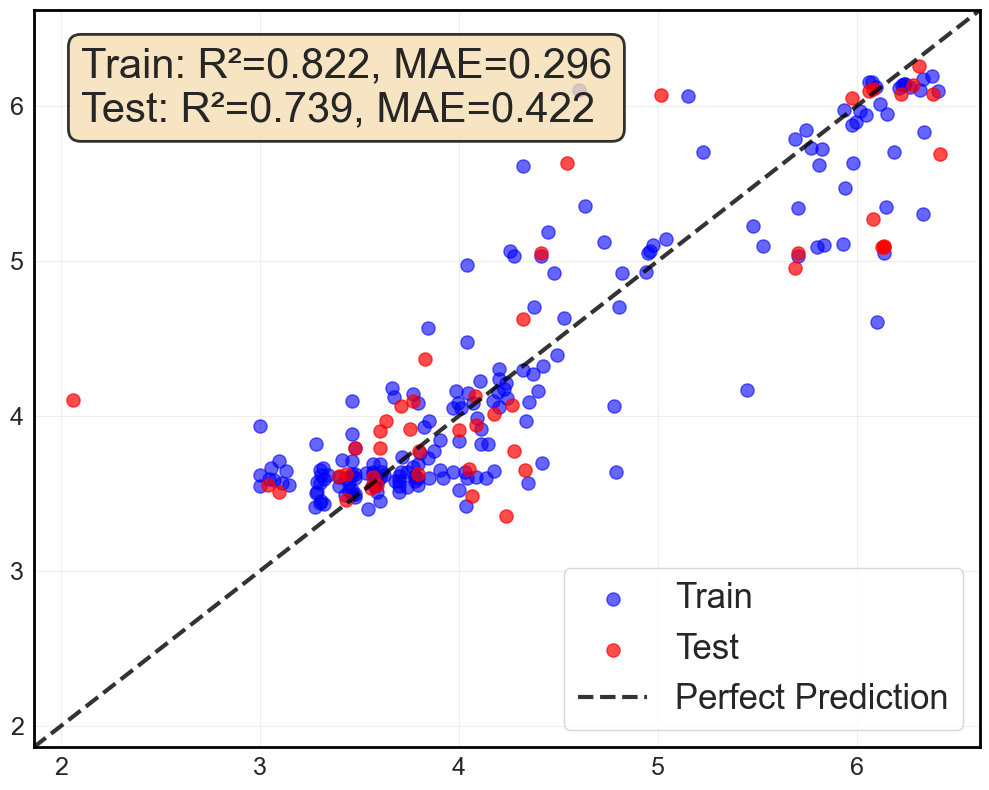

Genus - SVR 예측 vs 실제값 그래프가 'model_result/prediction_plots/Genus_SVR_regression_prediction_vs_actual.png'에 저장되었습니다.


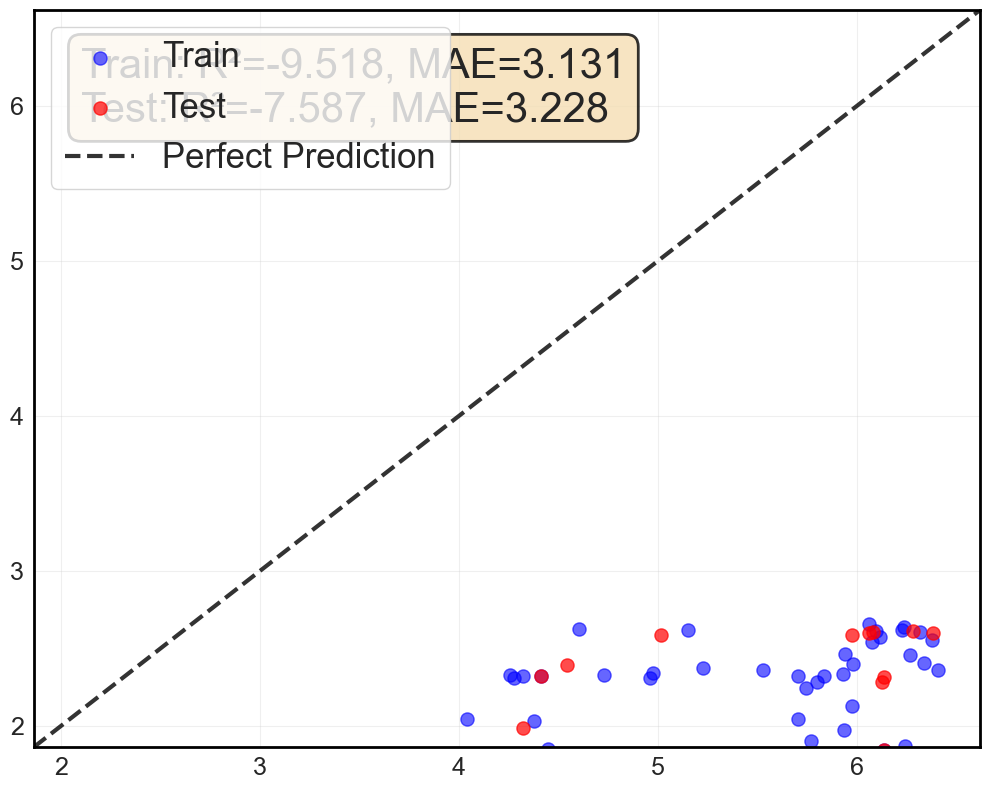

Genus - LSTM 예측 vs 실제값 그래프가 'model_result/prediction_plots/Genus_LSTM_regression_prediction_vs_actual.png'에 저장되었습니다.


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import os

plot_dir = "model_result/prediction_plots"
os.makedirs(plot_dir, exist_ok=True)

def plot_prediction_vs_actual(level_name, model_name, y_train, y_train_pred, y_test, y_test_pred, train_r2, test_r2, train_mae, test_mae, save_path):
    """예측값 vs 실제값 산점도 (논문용 디자인 완벽 통일)"""
    fig, ax = plt.subplots(figsize=(10, 8))
    # 산점도
    ax.scatter(y_train, y_train_pred, alpha=0.6, s=90, label='Train', color='blue')
    ax.scatter(y_test, y_test_pred, alpha=0.7, s=90, label='Test', color='red')
    # 완벽 예측선
    min_val = min(np.min(y_train), np.min(y_test)) - 0.2
    max_val = max(np.max(y_train), np.max(y_test)) + 0.2
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=3, label='Perfect Prediction')
    # 성능 텍스트 박스
    textstr = f'Train: R²={train_r2:.3f}, MAE={train_mae:.3f}\nTest: R²={test_r2:.3f}, MAE={test_mae:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=2)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=30, verticalalignment='top', bbox=props)
    # 축/타이틀 폰트 크기 및 굵기
    ax.legend(fontsize=25)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, alpha=0.3)
    # 테두리
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Genus level만 논문용 디자인으로 저장
for level_name, level_df in final_taxonomic_levels_with_label:
    if level_name != "Genus":
        continue
    fresh_spoilage_df = level_df[level_df['Label'].isin([0, 2])].copy()
    if len(fresh_spoilage_df) < 10:
        continue
    feature_cols = [col for col in fresh_spoilage_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS', 'Label', 'Day']]
    X = fresh_spoilage_df[feature_cols].values
    y = fresh_spoilage_df['TPC (log CFU/g)'].values
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    if level_name not in regression_results:
        continue
    model_names = ['LightGBM', 'RandomForest', 'XGBoost', 'SVR', 'LSTM']
    for model_name in model_names:
        if model_name not in regression_results[level_name]:
            continue
        best_model = regression_results[level_name][model_name]['GridSearchCV'].best_estimator_
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)
        train_r2 = regression_results[level_name][model_name]['Train_R2']
        test_r2 = regression_results[level_name][model_name]['Test_R2']
        train_mae = regression_results[level_name][model_name]['Train_MAE']
        test_mae = regression_results[level_name][model_name]['Test_MAE']
        save_path = os.path.join(plot_dir, f'{level_name}_{model_name}_regression_prediction_vs_actual.png')
        plot_prediction_vs_actual(level_name, model_name, y_train, y_train_pred, y_test, y_test_pred, train_r2, test_r2, train_mae, test_mae, save_path)
        print(f"{level_name} - {model_name} 예측 vs 실제값 그래프가 '{save_path}'에 저장되었습니다.")

In [7]:
# GridSearchCV 결과를 엑셀 파일로 저장
grid_search_results = []

for level_name, res_dict in regression_results.items():
    for model_name, metrics in res_dict.items():
        grid = metrics["GridSearchCV"]
        if grid is not None:
            for params, mean_score, std_score in zip(grid.cv_results_["params"], 
                                                     grid.cv_results_["mean_test_score"], 
                                                     grid.cv_results_["std_test_score"]):
                grid_search_results.append({
                    "Taxonomy_Level": level_name,
                    "Model": model_name,
                    "Params": str(params),
                    "Mean_Test_Score": mean_score,
                    "Std_Test_Score": std_score
                })

# DataFrame 생성
df_grid_search = pd.DataFrame(grid_search_results)

# 엑셀로 저장
grid_search_excel_path = os.path.join(result_dir, "grid_search_results.xlsx")
df_grid_search.to_excel(grid_search_excel_path, index=False)

print(f"GridSearchCV 결과가 '{grid_search_excel_path}'에 저장되었습니다.")

GridSearchCV 결과가 'model_result/grid_search_results.xlsx'에 저장되었습니다.
